In [5]:
import pandas as pd

# Datei einlesen
df = pd.read_csv("../../data_cleanup/df_sars_hum_cleaned_final.csv", sep="\t")

# Nur die interessanten Spalten auswählen (optional)
df_subclasses = df[['heavy_subclass', 'light_subclass', 'antigen_name']]

# Eindeutige Kombinationen aus heavy_subclass und antigen_name behalten, dann zählen wie oft jede heavy_subclass vorkommt
counts = df_subclasses[['heavy_subclass', 'antigen_name']] \
    .drop_duplicates() \
    .groupby('heavy_subclass') \
    .size() \
    .reset_index(name='count')

print(counts)

  heavy_subclass  count
0          IGHV1    119
1         IGHV14      5
2          IGHV2     17
3          IGHV3    197
4          IGHV4     45
5          IGHV5     31
6          IGHV6     11
7          IGHV7      8
8          IGHV9      2


Here is a count of the diffrent entries of antigen_species relative to the gene family. Since there are some entries that contain more than just homo sapiens or SarsCOV2, I decided to not include them in further analysis. 

In [12]:
import pandas as pd

# Datei einlesen
df = pd.read_csv("../../data_cleanup/df_sars_hum_cleaned_final.csv", sep="\t")

# Gruppieren und zählen
counts = df.groupby(['antigen_species', 'heavy_subclass']).size().reset_index(name='count')

print(counts)

# Optional: Pivot-Tabelle für bessere Übersicht
pivot_table = counts.pivot(index='antigen_species', columns='heavy_subclass', values='count').fillna(0).astype(int)
print(pivot_table)

                                      antigen_species heavy_subclass  count
0                           bos taurus | homo sapiens          IGHV3      1
1                                hiv-1 | homo sapiens          IGHV1      1
2                                        homo sapiens          IGHV1    258
3                                        homo sapiens         IGHV14     14
4                                        homo sapiens          IGHV2     15
5                                        homo sapiens          IGHV3    458
6                                        homo sapiens          IGHV4     93
7                                        homo sapiens          IGHV5     41
8                                        homo sapiens          IGHV6     12
9                                        homo sapiens          IGHV7      8
10                                       homo sapiens          IGHV9      2
11                                    homo sapiens |           IGHV3      6
12          

This code creates a dendogram on basis of a hierachial clustering of the gene families based on which antigen is targeted to whcih extent. Aditionally a cophenetic clustering is carried out, to compare the two gene family dendograms to eachother ("Pylogenetic tree of consensus sequences" from consensus_genfam.ipynb)

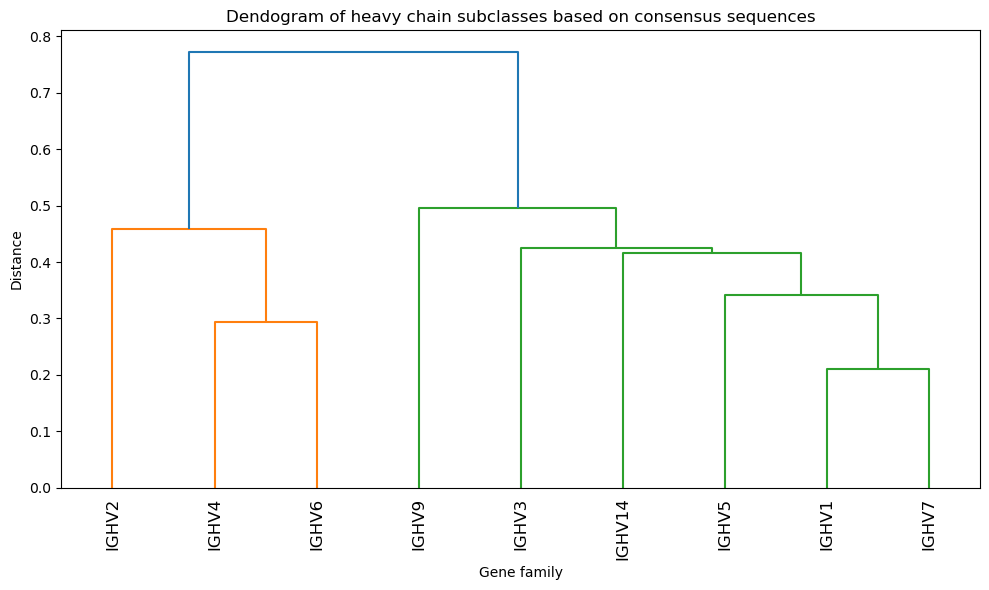

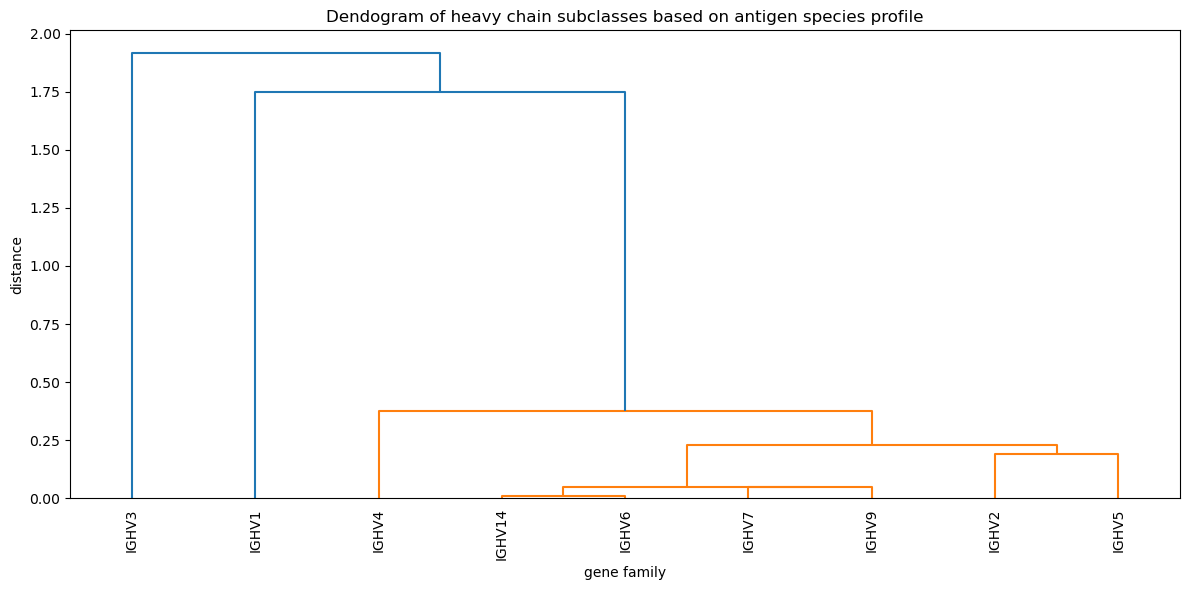

Cophenetische Korrelation erstes Cluster: 0.774
Cophenetische Korrelation zweites Cluster: 0.928
Cophenetische Korrelation zwischen den beiden Dendrogrammen: -0.188


In [22]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram, cophenet
from scipy.spatial.distance import squareform, pdist
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ------------------------
# Erster Datensatz: Distanzmatrix einlesen und Linkage berechnen
# ------------------------

# Pfad zur Distanzmatrix (achte auf korrekten Pfad)
file_path = "msa_consensus_output/distance_matrix.txt"

with open(file_path, "r") as f:
    lines = f.readlines()

n = int(lines[0].strip())

labels_1 = []
matrix = []

for line in lines[1:]:
    parts = line.strip().split()
    label = parts[0]
    values = list(map(float, parts[1:]))
    labels_1.append(label)
    matrix.append(values)

df = pd.DataFrame(matrix, index=labels_1, columns=labels_1)

# Sicherstellen, dass quadratisch
assert df.shape[0] == df.shape[1], "Distance matrix muss quadratisch sein!"

# Distanzmatrix als float
matrix_float = df.values.astype(float)

# Kondensierte Distanzmatrix (für linkage)
condensed_dist_1 = squareform(matrix_float)

# Linkage berechnen (Ward)
Z1 = linkage(condensed_dist_1, method='ward')

# Dendrogramm zeichnen
plt.figure(figsize=(10, 6))
dendrogram(Z1, labels=labels_1, leaf_rotation=90)
plt.title("Dendogram of heavy chain subclasses based on consensus sequences")
plt.xlabel("Gene family")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

# ------------------------
# Zweiter Datensatz: CSV einlesen und Linkage berechnen
# ------------------------

df2 = pd.read_csv("../../data_cleanup/df_sars_hum_cleaned_final.csv", sep="\t")

df2["antigen_species"] = df2["antigen_species"].str.split("|").apply(lambda x: [s.strip() for s in x])
df2_exploded = df2.explode("antigen_species")

relevant_species = ["severe acute respiratory syndrome coronavirus2", "homo sapiens"]
df2_filtered = df2_exploded[df2_exploded["antigen_species"].isin(relevant_species)]

pivot = df2_filtered.pivot_table(
    index="heavy_subclass",
    columns="antigen_species",
    aggfunc="size",
    fill_value=0
)

pivot_scaled = StandardScaler().fit_transform(pivot)

Z2 = linkage(pivot_scaled, method="single", metric="euclidean")

plt.figure(figsize=(12, 6))
dendrogram(
    Z2,
    labels=pivot.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=None
)
plt.title("Dendogram of heavy chain subclasses based on antigen species profile")
plt.xlabel("gene family")
plt.ylabel("distance")
plt.tight_layout()
plt.show()

# ------------------------
# Cophenetische Korrelation zur Bewertung der Ähnlichkeit der Cluster
# ------------------------

# Cophenetische Distanz für erstes Clustering (basierend auf der ersten Distanzmatrix)
coph_corr_1, coph_dist_1 = cophenet(Z1, condensed_dist_1)

# Cophenetische Distanz für zweites Clustering (basierend auf pivot_scaled)
condensed_dist_2 = pdist(pivot_scaled, metric='euclidean')
coph_corr_2, coph_dist_2 = cophenet(Z2, condensed_dist_2)

print(f"Cophenetische Korrelation erstes Cluster: {coph_corr_1:.3f}")
print(f"Cophenetische Korrelation zweites Cluster: {coph_corr_2:.3f}")

# ------------------------
# Vergleich der beiden Dendrogramme via cophenetischer Distanz
# ------------------------

# Für Vergleich brauchen wir die cophenetischen Distanzen (Arrays) beider Cluster
# Beide Arrays haben Länge n*(n-1)/2, n = Anzahl Clusterpunkte

# Jetzt kann man z.B. die Korrelation zwischen den beiden cophenetischen Distanzarrays berechnen:
correlation_between_clusters = np.corrcoef(coph_dist_1, coph_dist_2)[0,1]
print(f"Cophenetische Korrelation zwischen den beiden Dendrogrammen: {correlation_between_clusters:.3f}")

Calculating spearman correlation of both clusters: 

In [21]:
from scipy.stats import spearmanr

corr, pval = spearmanr(coph_dist_1, coph_dist_2)

print(f"Spearman correlation between dendrograms: {corr:.3f} (p = {pval:.3g})")

Spearman correlation between dendrograms: -0.157 (p = 0.361)


It is also a result for our presentation. To run this Code you need the file df_sars_hum_cleaned_final.csv and "Pylogenetic tree of consensus sequences" from consensus_genfam.ipynb

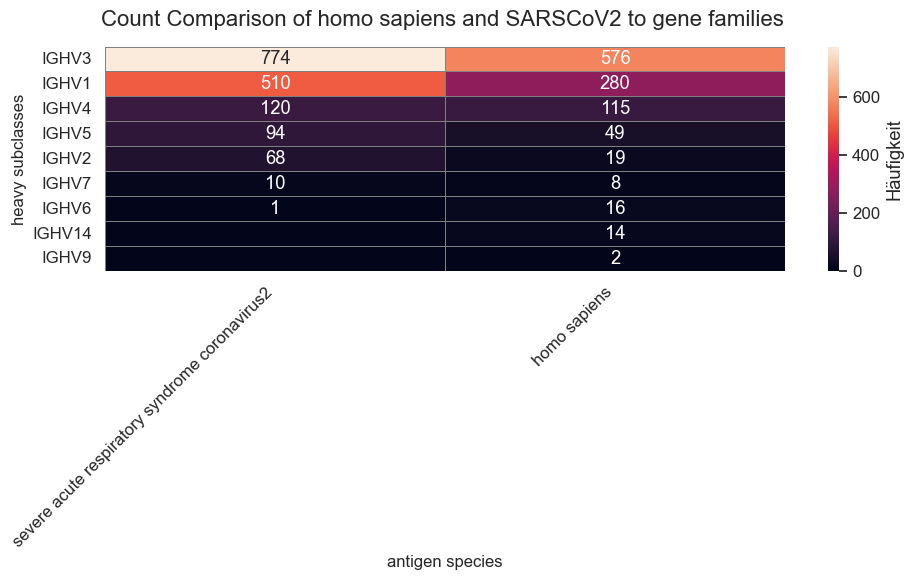

In [73]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------
# 1. CSV einlesen (Tabulator-getrennt)
# -------------------------------
df = pd.read_csv("../../data_cleanup/df_sars_hum_cleaned_final.csv", sep="\t")

# -------------------------------
# 2. antigen_species aufsplitten & explodieren
# -------------------------------
df["antigen_species"] = df["antigen_species"].str.split("|").apply(lambda x: [s.strip() for s in x])
df_exploded = df.explode("antigen_species")

# -------------------------------
# 3. Nur gewünschte Spezies behalten
# -------------------------------
relevant_species = ["severe acute respiratory syndrome coronavirus2", "homo sapiens"]
df_filtered = df_exploded[df_exploded["antigen_species"].isin(relevant_species)]

# -------------------------------
# 4. Pivot-Tabelle erstellen (Zählung)
# -------------------------------
pivot = df_filtered.pivot_table(
    index="heavy_subclass",
    columns="antigen_species",
    aggfunc="size",
    fill_value=0
)

# -------------------------------
# 5. Achsen sortieren nach Häufigkeit
# -------------------------------
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]
pivot = pivot[pivot.sum(axis=0).sort_values(ascending=False).index]

# -------------------------------
# 6. Werte für Annotation vorbereiten
# -------------------------------
annotations = pivot.copy()
annotations = annotations.where(annotations > 0, "")
annotations = annotations.astype(str)

# -------------------------------
# 7. Heatmap plotten
# -------------------------------
plt.figure(figsize=(10, 6))
sns.set(font_scale=1.1)
sns.heatmap(
    pivot,
    annot=annotations,
    fmt="s",
    cmap="rocket",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Häufigkeit"},
    square=False
)

plt.title("Count Comparison of homo sapiens and SARSCoV2 to gene families ", fontsize=16, pad=15)
plt.xlabel("antigen species", fontsize=12)
plt.ylabel("heavy subclasses", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()